# Motion-S: Text-to-Sign Motion Generation

**Competition**: Hierarchical Text-to-Motion Generation for Sign Language  
**Approach**: CLIP text encoder → Transformer decoder → 6-layer RVQ token generation  
**Key metrics**: R-Precision (50%), FID (30%), Diversity (20%)

---

## 0. Setup & Configuration

In [2]:
import os, gc, json, math, random, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [3]:
# ── Auto-discover data paths ──
import glob

# Find competition data directory
INPUT_DIR = None
for d in sorted(Path('/kaggle/input').iterdir()):
    if (d / 'train.csv').exists():
        INPUT_DIR = d
        break
if INPUT_DIR is None:
    # Fallback: search recursively
    hits = glob.glob('/kaggle/input/**/train.csv', recursive=True)
    if hits:
        INPUT_DIR = Path(hits[0]).parent
assert INPUT_DIR is not None, 'Could not find train.csv in /kaggle/input/'
print(f'Data directory: {INPUT_DIR}')
print(f'Contents: {[f.name for f in INPUT_DIR.iterdir()]}')

# Upload CLIP as a Kaggle dataset for offline inference:
CLIP_DIR = Path('/kaggle/input/openai-clip')  # contains clip-vit-base-patch32/
OUTPUT_DIR = Path('/kaggle/working')

TRAIN_CSV = INPUT_DIR / 'train.csv'
TEST_CSV  = INPUT_DIR / 'test.csv'
SAMPLE_SUB = INPUT_DIR / 'sample_submission.csv'

TOKEN_COLS = ['base_tokens', 'residual_1', 'residual_2',
              'residual_3', 'residual_4', 'residual_5']

class CFG:
    num_codebook   = 512     # token values 0..511
    num_layers     = 6       # base + 5 residuals
    max_seq_len    = 800
    min_seq_len    = 40
    text_embed_dim = 512     # CLIP ViT-B/32
    d_model        = 512
    nhead          = 8
    num_dec_layers = 6
    dim_ff         = 2048
    dropout        = 0.1
    batch_size     = 32
    lr             = 1e-4
    weight_decay   = 1e-2
    epochs         = 30
    warmup_steps   = 500
    grad_clip      = 1.0
    len_bins       = 20
    temperature    = 0.9
    top_k          = 50
    top_p          = 0.95

print('Config loaded.')

Data directory: /kaggle/input/competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language
Contents: ['sample_submission.csv', 'Motion-Features', 'train.csv', 'test.csv', 'Train']
Config loaded.


## 1. Data Loading & EDA

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

def parse_tokens(s):
    if pd.isna(s) or str(s).strip() == '':
        return []
    return list(map(int, str(s).strip().split()))

train_df['seq_len']    = train_df['base_tokens'].apply(lambda x: len(parse_tokens(x)))
train_df['gloss_words'] = train_df['gloss'].apply(lambda x: len(str(x).split()))
train_df['sent_words']  = train_df['sentence'].apply(lambda x: len(str(x).split()))

print(f'Train: {len(train_df)} | Test: {len(test_df)}')
print(f'Seq length: min={train_df["seq_len"].min()}, max={train_df["seq_len"].max()}, '
      f'mean={train_df["seq_len"].mean():.1f}')
print(f'Zero-length: {(train_df["seq_len"]==0).sum()}')
train_df.head(3)

Train: 12467 | Test: 3000
Seq length: min=0, max=1853, mean=108.1
Zero-length: 4


,id,sentence,gloss,bvh_path,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5,seq_len,gloss_words,sent_words
0,1000648,Don't keep me on tenterhooks!,KEEP ME TENTHOOK//,dataset/1000648/1000648.bvh,379 295 376 376 376 376 376 376 133 133 376 37...,339 441 88 87 87 87 88 288 405 333 333 248 212...,406 183 8 301 476 6 169 255 452 462 66 255 463...,315 424 330 104 364 104 142 142 166 353 353 10...,64 32 15 326 466 20 229 456 71 71 71 390 20 90...,306 376 367 367 133 235 276 350 367 350 437 36...,81,3,5
1,1002815,"I like to be home, that way I can work on my s...",ME LIKE HOME WORK STORY FINISH//,dataset/1002815/1002815.bvh,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...,120,6,13
2,1003115,Can I stay here tonight?,STAY HERE TONIGHT ME?,dataset/1003115/1003115.bvh,379 185 185 185 185 185 185 185 185 185 185 18...,339 441 87 87 88 88 88 288 308 88 325 483 483 ...,396 171 11 11 211 211 321 430 464 464 283 267 ...,65 449 376 191 503 503 142 166 384 143 384 348...,64 230 328 411 349 71 424 71 498 456 234 85 34...,306 201 367 6 266 406 123 71 343 428 38 404 37...,94,4,5


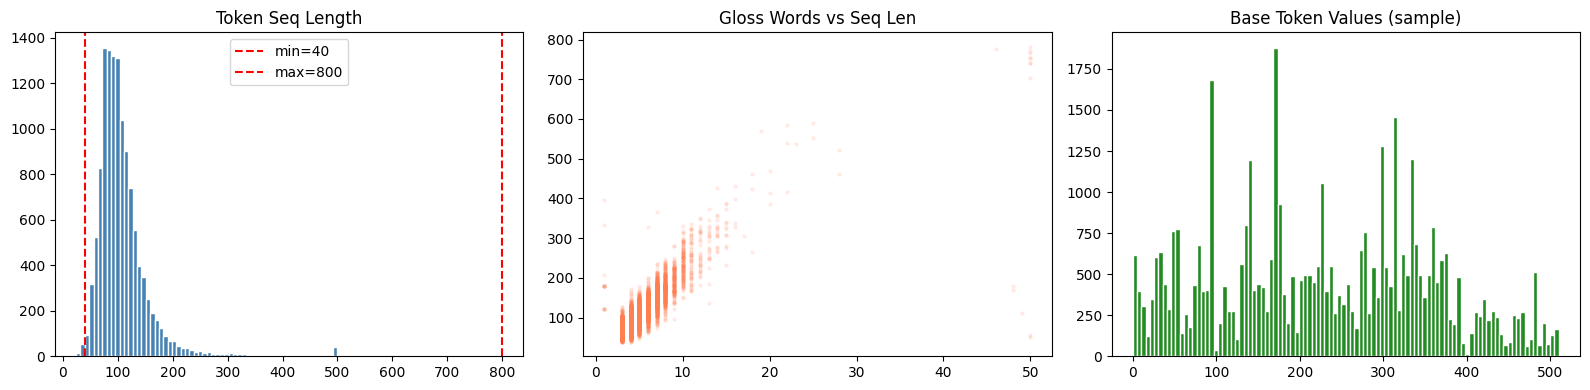

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

vl = train_df[train_df['seq_len'] > 0]['seq_len']
axes[0].hist(vl.clip(upper=500), bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(40, color='red', ls='--', label='min=40')
axes[0].axvline(800, color='red', ls='--', label='max=800')
axes[0].set_title('Token Seq Length'); axes[0].legend()

v = train_df[(train_df['seq_len']>=40)&(train_df['seq_len']<=800)]
axes[1].scatter(v['gloss_words'], v['seq_len'], alpha=0.1, s=5, color='coral')
axes[1].set_title('Gloss Words vs Seq Len')

st = []
for _, r in train_df.head(500).iterrows():
    st.extend(parse_tokens(r['base_tokens'])[:100])
axes[2].hist(st, bins=100, color='forestgreen', edgecolor='white')
axes[2].set_title('Base Token Values (sample)')
plt.tight_layout(); plt.show()

In [6]:
train_valid = train_df[
    (train_df['seq_len'] >= CFG.min_seq_len) &
    (train_df['seq_len'] <= CFG.max_seq_len)
].copy().reset_index(drop=True)
print(f'Valid training: {len(train_valid)} / {len(train_df)}')

Valid training: 12373 / 12467


## 2. CLIP Text Encoder

Frozen CLIP ViT-B/32 as text encoder. Upload HuggingFace `openai/clip-vit-base-patch32` as a Kaggle dataset for offline inference.

In [22]:
try:
    from transformers import CLIPTokenizer, CLIPTextModel
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'transformers'])
    from transformers import CLIPTokenizer, CLIPTextModel

# For Kaggle offline: clip_path = str(CLIP_DIR / 'clip-vit-base-patch32')
# For dev with internet:
clip_path = 'openai/clip-vit-base-patch32'

clip_tokenizer = CLIPTokenizer.from_pretrained(clip_path)
# Load CLIP on CPU to avoid P100 CUDA kernel compatibility issues.
# Encoding is a one-time cost; GPU is reserved for the main model training.
CLIP_DEVICE = torch.device('cpu')
clip_model = CLIPTextModel.from_pretrained(clip_path).to(CLIP_DEVICE).eval()
for p in clip_model.parameters(): p.requires_grad = False
print(f'CLIP loaded on {CLIP_DEVICE}: {sum(p.numel() for p in clip_model.parameters())/1e6:.1f}M params (frozen)')

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

CLIP loaded on cpu: 63.2M params (frozen)


In [23]:
@torch.no_grad()
def encode_texts(texts, batch_size=64):
    """Encode texts -> CLIP pooled embeddings [N, 512]."""
    all_e = []
    for i in range(0, len(texts), batch_size):
        inp = clip_tokenizer(texts[i:i+batch_size], padding='max_length',
                             truncation=True, max_length=77,
                             return_tensors='pt').to(CLIP_DEVICE)
        out = clip_model(**inp)
        all_e.append(F.normalize(out.pooler_output, dim=-1).cpu())
    return torch.cat(all_e, 0)

@torch.no_grad()
def encode_texts_hidden(texts, batch_size=64):
    """Encode texts -> (hidden_states, pooled, mask). All padded to max_length=77."""
    h_list, p_list, m_list = [], [], []
    for i in range(0, len(texts), batch_size):
        inp = clip_tokenizer(texts[i:i+batch_size], padding='max_length',
                             truncation=True, max_length=77,
                             return_tensors='pt').to(CLIP_DEVICE)
        out = clip_model(**inp, output_hidden_states=True)
        h_list.append(out.last_hidden_state.cpu())
        p_list.append(out.pooler_output.cpu())
        m_list.append(inp['attention_mask'].cpu())
    return torch.cat(h_list,0), torch.cat(p_list,0), torch.cat(m_list,0)

# Quick test
_ = encode_texts(['hello world'])
print(f'CLIP encoding OK, dim={_.shape[-1]}')

CLIP encoding OK, dim=512


In [24]:
def make_text(row):
    return f"{str(row['sentence']).strip()} [SEP] {str(row['gloss']).strip()}"

print('Encoding train texts (on CPU, one-time)...')
train_texts = [make_text(r) for _, r in train_valid.iterrows()]
train_hidden, train_pooled, train_tmask = encode_texts_hidden(train_texts)
print(f'  hidden={train_hidden.shape}, pooled={train_pooled.shape}')

print('Encoding test texts...')
test_texts = [make_text(r) for _, r in test_df.iterrows()]
test_hidden, test_pooled, test_tmask = encode_texts_hidden(test_texts)
print(f'  hidden={test_hidden.shape}, pooled={test_pooled.shape}')

# Encode gloss-only embeddings for retrieval (before freeing CLIP)
print('Encoding gloss embeddings for retrieval...')
tr_gloss_emb = encode_texts(train_valid['gloss'].tolist())
te_gloss_emb = encode_texts(test_df['gloss'].tolist())
print(f'  train gloss: {tr_gloss_emb.shape}, test gloss: {te_gloss_emb.shape}')

# Free CLIP from memory — no longer needed
del clip_model
gc.collect()
torch.cuda.empty_cache()
print('CLIP freed from memory.')

Encoding train texts (on CPU, one-time)...
  hidden=torch.Size([12373, 77, 512]), pooled=torch.Size([12373, 512])
Encoding test texts...
  hidden=torch.Size([3000, 77, 512]), pooled=torch.Size([3000, 512])
Encoding gloss embeddings for retrieval...
  train gloss: torch.Size([12373, 512]), test gloss: torch.Size([3000, 512])
CLIP freed from memory.


## 3. Length Predictor

In [25]:
class LengthPredictor(nn.Module):
    def __init__(self, d_in=512, d_hid=256, n_bins=20):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hid), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(d_hid, d_hid), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(d_hid, n_bins))
    def forward(self, x): return self.net(x)

# Build quantile-based bins
train_lengths = train_valid['seq_len'].values
bin_edges = np.unique(np.quantile(train_lengths,
                      np.linspace(0,1,CFG.len_bins+1)).astype(int))
bin_edges[0] = CFG.min_seq_len; bin_edges[-1] = CFG.max_seq_len
n_bins = len(bin_edges)-1

def len2bin(l): return min(np.searchsorted(bin_edges[1:], l), n_bins-1)
def bin2len(b): return (bin_edges[min(b,len(bin_edges)-2)] + bin_edges[min(b+1,len(bin_edges)-1)])//2

train_lbins = np.array([len2bin(l) for l in train_lengths])
print(f'Length bins: {n_bins}, edges: {bin_edges}')

Length bins: 20, edges: [ 40  58  67  72  76  79  83  87  91  94  98 102 106 111 116 122 129 139
 152 180 800]


In [26]:
# Train length predictor
len_pred = LengthPredictor(d_in=512, d_hid=256, n_bins=n_bins).to(DEVICE)
len_opt = torch.optim.AdamW(len_pred.parameters(), lr=1e-3, weight_decay=1e-2)

X_l = torch.tensor(train_pooled.numpy(), dtype=torch.float32)
y_l = torch.tensor(train_lbins, dtype=torch.long)
ld = DataLoader(torch.utils.data.TensorDataset(X_l, y_l), batch_size=256, shuffle=True)

len_pred.train()
for ep in range(30):
    tot, cor, cnt = 0., 0, 0
    for xb, yb in ld:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = F.cross_entropy(len_pred(xb), yb)
        len_opt.zero_grad(); loss.backward(); len_opt.step()
        tot += loss.item()*len(xb); cor += (len_pred(xb).argmax(-1)==yb).sum().item(); cnt += len(xb)
    if (ep+1)%10==0: print(f'Ep {ep+1}: loss={tot/cnt:.4f} acc={cor/cnt:.3f}')
len_pred.eval()
print('Length predictor trained.')

Ep 10: loss=1.6599 acc=0.487
Ep 20: loss=0.7344 acc=0.787
Ep 30: loss=0.3569 acc=0.906
Length predictor trained.


## 4. Dataset & DataLoader

In [27]:
class MotionDS(Dataset):
    def __init__(self, df, t_hid, t_pool, t_mask, max_len=800):
        self.t_hid, self.t_pool, self.t_mask = t_hid, t_pool, t_mask
        self.max_len = max_len
        self.tokens = []
        for i in range(len(df)):
            row = df.iloc[i]
            layers = [parse_tokens(row[c]) for c in TOKEN_COLS]
            self.tokens.append(layers)
    def __len__(self): return len(self.tokens)
    def __getitem__(self, i):
        layers = self.tokens[i]
        sl = min(len(layers[0]), self.max_len)
        arr = np.array([l[:sl] for l in layers], dtype=np.int64)
        return dict(t_hid=self.t_hid[i], t_pool=self.t_pool[i],
                    t_mask=self.t_mask[i], tok=arr, sl=sl)

def collate(batch):
    B = len(batch)
    mx_t = max(b['t_hid'].shape[0] for b in batch)
    mx_s = max(b['sl'] for b in batch)
    D = batch[0]['t_hid'].shape[-1]
    t_h = torch.zeros(B, mx_t, D)
    t_p = torch.stack([b['t_pool'] for b in batch])
    t_m = torch.zeros(B, mx_t, dtype=torch.long)
    tok = torch.zeros(B, 6, mx_s, dtype=torch.long)
    tmask = torch.zeros(B, mx_s, dtype=torch.bool)
    sls = torch.tensor([b['sl'] for b in batch])
    for i, b in enumerate(batch):
        tl, sl = b['t_hid'].shape[0], b['sl']
        t_h[i,:tl] = b['t_hid']; t_m[i,:tl] = b['t_mask']
        tok[i,:,:sl] = torch.tensor(b['tok']); tmask[i,:sl] = True
    return dict(t_h=t_h, t_p=t_p, t_m=t_m, tok=tok, tmask=tmask, sls=sls)

ds = MotionDS(train_valid, train_hidden, train_pooled, train_tmask)
dl = DataLoader(ds, batch_size=CFG.batch_size, shuffle=True,
                collate_fn=collate, num_workers=2, pin_memory=True, drop_last=True)
print(f'Dataset: {len(ds)} samples, {len(dl)} batches')
b0 = next(iter(dl))
for k,v in b0.items(): print(f'  {k}: {v.shape}')

Dataset: 12373 samples, 386 batches
  t_h: torch.Size([32, 77, 512])
  t_p: torch.Size([32, 512])
  t_m: torch.Size([32, 77])
  tok: torch.Size([32, 6, 217])
  tmask: torch.Size([32, 217])
  sls: torch.Size([32])


## 5. Model Architecture

Cross-attention Transformer decoder conditioned on CLIP features.  
Generates all 6 RVQ layers in parallel at each time step.

In [28]:
class PosEnc(nn.Module):
    def __init__(self, d, max_len=1024, drop=0.1):
        super().__init__()
        self.drop = nn.Dropout(drop)
        pe = torch.zeros(max_len, d)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.)/d))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.drop(x + self.pe[:,:x.size(1)])

class MotionGen(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg.d_model
        self.cfg = cfg
        # Per-layer token embeddings
        edim = d // 6  # 85 for d=512
        self.tok_embs = nn.ModuleList([nn.Embedding(cfg.num_codebook, edim) for _ in range(6)])
        self.inp_proj = nn.Linear(edim * 6, d)
        self.start_tok = nn.Parameter(torch.randn(1, 1, d))
        self.pos_enc = PosEnc(d, max_len=cfg.max_seq_len+1, drop=cfg.dropout)
        self.txt_proj = nn.Linear(cfg.text_embed_dim, d)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d, nhead=cfg.nhead, dim_feedforward=cfg.dim_ff,
            dropout=cfg.dropout, activation='gelu', batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=cfg.num_dec_layers)
        self.heads = nn.ModuleList([
            nn.Sequential(nn.LayerNorm(d), nn.Linear(d, cfg.num_codebook))
            for _ in range(6)])

    def _cmask(self, sz, dev):
        return torch.triu(torch.ones(sz,sz,device=dev)*float('-inf'), diagonal=1)

    def embed_tok(self, tok):
        # tok: [B,6,T]
        parts = [self.tok_embs[i](tok[:,i,:]) for i in range(6)]
        return self.inp_proj(torch.cat(parts, -1))

    def forward(self, t_h, t_m, tok, tmask):
        B, _, T = tok.shape
        mem = self.txt_proj(t_h)
        mem_kpm = ~t_m.bool()
        te = self.embed_tok(tok)
        di = torch.cat([self.start_tok.expand(B,-1,-1), te[:,:-1,:]], 1)
        di = self.pos_enc(di)
        cm = self._cmask(T, tok.device)
        out = self.decoder(tgt=di, memory=mem, tgt_mask=cm,
                           tgt_key_padding_mask=~tmask,
                           memory_key_padding_mask=mem_kpm)
        return torch.stack([h(out) for h in self.heads], 1)  # [B,6,T,512]

    @torch.no_grad()
    def generate(self, t_h, t_m, seq_len, temp=0.9, top_k=50, top_p=0.95):
        dev = t_h.device
        mem = self.txt_proj(t_h)
        mem_kpm = ~t_m.bool()
        seq = self.start_tok  # [1,1,d]
        gen = []
        for t in range(seq_len):
            tgt = seq + self.pos_enc.pe[:,:seq.size(1)]
            cm = self._cmask(tgt.size(1), dev)
            out = self.decoder(tgt=tgt, memory=mem, tgt_mask=cm,
                               memory_key_padding_mask=mem_kpm)
            h = out[:,-1:,:]
            ltoks = []
            for head in self.heads:
                logits = head(h).squeeze(1) / temp
                if top_k > 0:
                    kv, _ = torch.topk(logits, top_k)
                    logits[logits < kv[:,-1:]] = float('-inf')
                if top_p < 1.0:
                    sl, si = torch.sort(logits, descending=True)
                    cp = torch.cumsum(F.softmax(sl,-1), -1)
                    rm = cp > top_p; rm[:,1:] = rm[:,:-1].clone(); rm[:,0] = False
                    logits[rm.scatter(1, si, rm)] = float('-inf')
                ltoks.append(torch.multinomial(F.softmax(logits,-1), 1))
            step = torch.stack(ltoks, 1)  # [1,6,1]
            gen.append(step)
            seq = torch.cat([seq, self.embed_tok(step)], 1)
        return torch.cat(gen, 2).squeeze(0)  # [6, seq_len]

model = MotionGen(CFG).to(DEVICE)
print(f'Model params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M')

Model params: 27.59M


## 6. Training

In [29]:
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr,
                               weight_decay=CFG.weight_decay, betas=(0.9, 0.98))
total_steps = CFG.epochs * len(dl)

def lr_fn(step):
    if step < CFG.warmup_steps:
        return step / max(1, CFG.warmup_steps)
    prog = (step - CFG.warmup_steps) / max(1, total_steps - CFG.warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * prog))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_fn)
scaler = GradScaler()
ce = nn.CrossEntropyLoss(reduction='none')
print(f'Total steps: {total_steps}, warmup: {CFG.warmup_steps}')

Total steps: 11580, warmup: 500


In [30]:
best_loss = float('inf')
loss_hist = []
model.train()
gstep = 0

for epoch in range(CFG.epochs):
    eloss, etok = 0., 0
    for batch in dl:
        th = batch['t_h'].to(DEVICE)
        tm = batch['t_m'].to(DEVICE)
        tok = batch['tok'].to(DEVICE)
        tmask = batch['tmask'].to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            logits = model(th, tm, tok, tmask)  # [B,6,T,512]
            B, NL, T, V = logits.shape
            lf = ce(logits.reshape(-1,V), tok.reshape(-1))
            mf = tmask.unsqueeze(1).expand(-1,NL,-1).reshape(-1).float()
            loss = (lf * mf).sum() / mf.sum()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        nt = mf.sum().item(); eloss += loss.item()*nt; etok += nt; gstep += 1
        if gstep % 200 == 0:
            print(f'  step {gstep}: loss={eloss/etok:.4f} lr={scheduler.get_last_lr()[0]:.2e}')
    al = eloss/max(1,etok); loss_hist.append(al)
    print(f'Epoch {epoch+1}/{CFG.epochs}: loss={al:.4f}')
    if al < best_loss:
        best_loss = al
        torch.save(model.state_dict(), OUTPUT_DIR/'best_model.pth')
        print(f'  -> saved (loss={best_loss:.4f})')
print(f'\nBest loss: {best_loss:.4f}')

  step 200: loss=5.7424 lr=4.00e-05
Epoch 1/30: loss=5.2165
  -> saved (loss=5.2165)
  step 400: loss=4.2403 lr=8.00e-05
  step 600: loss=3.9179 lr=1.00e-04
Epoch 2/30: loss=3.7251
  -> saved (loss=3.7251)
  step 800: loss=3.3441 lr=9.98e-05
  step 1000: loss=3.2076 lr=9.95e-05
Epoch 3/30: loss=3.1489
  -> saved (loss=3.1489)
  step 1200: loss=2.9809 lr=9.90e-05
  step 1400: loss=2.9040 lr=9.84e-05
Epoch 4/30: loss=2.8693
  -> saved (loss=2.8693)
  step 1600: loss=2.7116 lr=9.76e-05
  step 1800: loss=2.7037 lr=9.66e-05
Epoch 5/30: loss=2.6823
  -> saved (loss=2.6823)
  step 2000: loss=2.5871 lr=9.55e-05
  step 2200: loss=2.5563 lr=9.43e-05
Epoch 6/30: loss=2.5398
  -> saved (loss=2.5398)
  step 2400: loss=2.4570 lr=9.29e-05
  step 2600: loss=2.4370 lr=9.14e-05
Epoch 7/30: loss=2.4264
  -> saved (loss=2.4264)
  step 2800: loss=2.3420 lr=8.97e-05
  step 3000: loss=2.3302 lr=8.80e-05
Epoch 8/30: loss=2.3315
  -> saved (loss=2.3315)
  step 3200: loss=2.2642 lr=8.61e-05
  step 3400: loss=2.

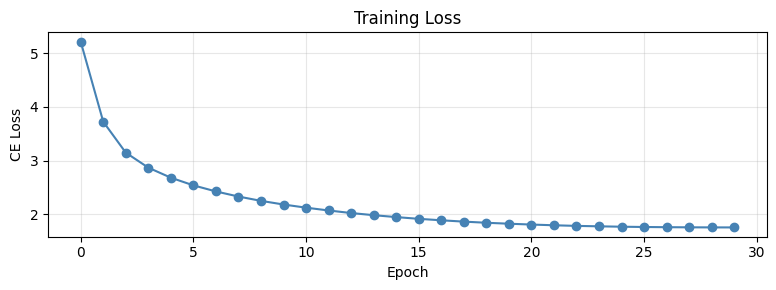

In [31]:
plt.figure(figsize=(8,3))
plt.plot(loss_hist, 'o-', color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('CE Loss'); plt.title('Training Loss')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 7. Retrieval Baseline (Fallback)

For each test sample, find most similar training sample by CLIP cosine similarity.

In [32]:
# Retrieval index already built (gloss embeddings computed earlier)
print('Building retrieval index...')

def topk_retrieve(te, tr, k=5, chunk=500):
    N = te.shape[0]
    idxs = np.zeros((N,k), dtype=np.int64)
    sims = np.zeros((N,k), dtype=np.float32)
    te_np, tr_np = te.numpy(), tr.numpy()
    for i in range(0, N, chunk):
        e = min(i+chunk, N)
        s = cosine_similarity(te_np[i:e], tr_np)
        for j in range(e-i):
            ix = np.argpartition(s[j],-k)[-k:]
            ix = ix[np.argsort(s[j][ix])[::-1]]
            idxs[i+j]=ix; sims[i+j]=s[j][ix]
    return idxs, sims

ret_idx, ret_sim = topk_retrieve(te_gloss_emb, tr_gloss_emb, k=5)
print(f'Top-1 avg sim: {ret_sim[:,0].mean():.4f}')

def get_ret_tokens(ti, k=0):
    row = train_valid.iloc[ret_idx[ti, k]]
    return [parse_tokens(row[c]) for c in TOKEN_COLS]

Building retrieval index...
Top-1 avg sim: 0.8622


## 8. Inference & Submission

In [33]:
model.load_state_dict(torch.load(OUTPUT_DIR/'best_model.pth', map_location=DEVICE))
model.eval()
print('Best model loaded.')

Best model loaded.


In [34]:
@torch.no_grad()
def pred_len(pooled):
    b = len_pred(pooled.unsqueeze(0).to(DEVICE)).argmax(-1).item()
    return max(CFG.min_seq_len, min(CFG.max_seq_len, bin2len(b)))

def generate_one(i, use_model=True):
    """Generate tokens for test sample i."""
    pl = pred_len(test_pooled[i])
    if use_model:
        try:
            th = test_hidden[i:i+1].to(DEVICE)
            tm = test_tmask[i:i+1].to(DEVICE)
            tok = model.generate(th, tm, pl,
                                 temp=CFG.temperature,
                                 top_k=CFG.top_k,
                                 top_p=CFG.top_p)
            return tok.clamp(0, 511).cpu().numpy()
        except Exception as e:
            print(f'  Model fail idx {i}: {e}')
    # Fallback: retrieval
    for k in range(5):
        layers = get_ret_tokens(i, k)
        sl = len(layers[0])
        if CFG.min_seq_len <= sl <= CFG.max_seq_len and sl > 0:
            return np.array(layers)
    # Emergency
    layers = get_ret_tokens(i, 0)
    sl = len(layers[0])
    if sl < CFG.min_seq_len:
        layers = [l + [l[-1]]*(CFG.min_seq_len-sl) for l in layers]
    elif sl > CFG.max_seq_len:
        layers = [l[:CFG.max_seq_len] for l in layers]
    return np.array(layers)

# Test
t0 = generate_one(0)
print(f'Test generation: shape={t0.shape}, range=[{t0.min()},{t0.max()}]')

Test generation: shape=(6, 108), range=[1,506]


In [35]:
print(f'Generating {len(test_df)} predictions...')
USE_MODEL = True
preds = {}
for i in range(len(test_df)):
    preds[test_df.iloc[i]['id']] = generate_one(i, use_model=USE_MODEL)
    if (i+1)%500==0: print(f'  {i+1}/{len(test_df)}')
print(f'Done: {len(preds)} predictions')

Generating 3000 predictions...
  500/3000
  1000/3000
  1500/3000
  2000/3000
  2500/3000
  3000/3000
Done: 3000 predictions


In [36]:
rows = []
for _, r in test_df.iterrows():
    tid = r['id']
    tok = preds[tid]
    d = {'id': tid}
    for li, cn in enumerate(TOKEN_COLS):
        d[cn] = ' '.join(map(str, tok[li].tolist()))
    rows.append(d)

sub = pd.DataFrame(rows)[['id'] + TOKEN_COLS]
sub.to_csv(OUTPUT_DIR / 'submission.csv', index=False)
print(f'Saved submission.csv: {len(sub)} rows')
sub.head(3)

Saved submission.csv: 3000 rows


,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,347 125 500 222 456 153 153 498 498 498 488 17...,474 313 367 445 372 167 367 394 241 295 66 225...
1,6420682,130 216 216 216 216 216 216 216 216 216 216 21...,339 441 333 333 333 333 333 9 9 9 9 9 9 9 87 8...,246 83 48 395 354 354 211 354 48 48 48 48 48 4...,130 320 308 401 401 191 282 424 424 424 87 191...,64 349 456 74 475 265 239 74 456 498 71 74 498...,71 428 367 182 367 437 367 367 469 241 241 241...
2,6425789,130 326 312 312 312 312 312 312 360 341 341 34...,339 441 87 87 87 87 87 9 9 9 9 333 483 483 493...,297 452 452 452 6 6 6 464 202 48 202 129 11 93...,72 429 315 87 22 397 397 424 308 503 384 76 49...,64 413 316 230 316 71 71 71 402 71 17 17 187 2...,306 305 367 367 347 117 437 367 367 117 186 43...


## 9. Validation

In [38]:
def validate(df, n_test=3000):
    errs = []
    if len(df) != n_test: errs.append(f'Row count: {len(df)} != {n_test}')
    for idx, row in df.iterrows():
        lens = []
        for c in TOKEN_COLS:
            toks = str(row[c]).split()
            lens.append(len(toks))
            for t in toks:
                v = int(t)
                if v < 0 or v > 511:
                    errs.append(f'Row {idx} {c}: val {v}'); break
        if len(set(lens)) != 1:
            errs.append(f'Row {idx}: inconsistent lens {lens}')
        if lens[0] < 40 or lens[0] > 800:
            errs.append(f'Row {idx}: len {lens[0]}')
        if len(errs) > 10: break
    return errs

errs = validate(sub)
if errs:
    print(f'ERRORS ({len(errs)}):')
    for e in errs: print(f'  x {e}')
else:
    print('Submission passed all checks!')

sl = sub['base_tokens'].apply(lambda x: len(str(x).split()))
print(f'Seq len: min={sl.min()}, max={sl.max()}, mean={sl.mean():.1f}')

Submission passed all checks!
Seq len: min=49, max=490, mean=121.6


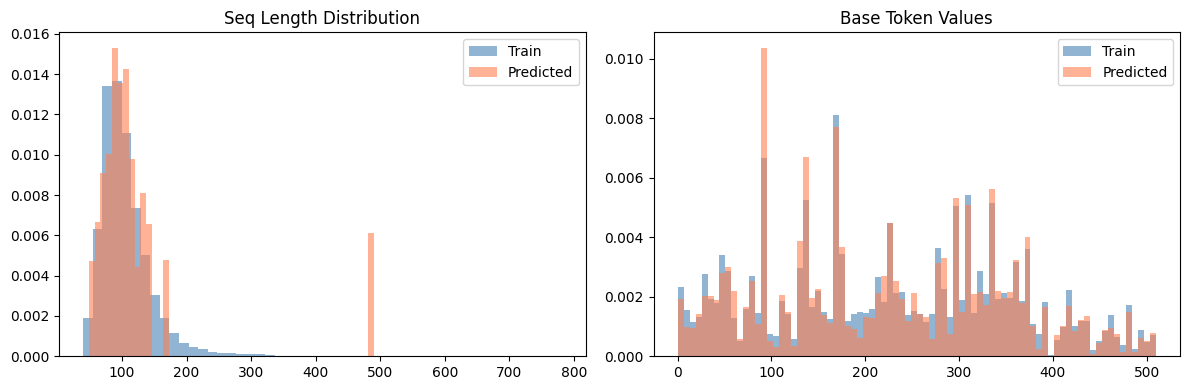

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(train_valid['seq_len'], bins=50, alpha=.6, label='Train', density=True, color='steelblue')
ax[0].hist(sl, bins=50, alpha=.6, label='Predicted', density=True, color='coral')
ax[0].set_title('Seq Length Distribution'); ax[0].legend()

tbf = []; gbf = []
for _, r in train_valid.head(1000).iterrows(): tbf.extend(parse_tokens(r['base_tokens'])[:100])
for _, r in sub.head(1000).iterrows(): gbf.extend(list(map(int, str(r['base_tokens']).split()[:100])))
ax[1].hist(tbf, bins=80, alpha=.6, label='Train', density=True, color='steelblue')
ax[1].hist(gbf, bins=80, alpha=.6, label='Predicted', density=True, color='coral')
ax[1].set_title('Base Token Values'); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Quick Retrieval-Only Submission (Alternative)

Fast no-training baseline for immediate submission.

In [41]:
def retrieval_submission():
    rows = []
    for i in range(len(test_df)):
        tid = test_df.iloc[i]['id']
        for k in range(5):
            layers = get_ret_tokens(i, k)
            sl = len(layers[0])
            if CFG.min_seq_len <= sl <= CFG.max_seq_len and sl > 0: break
        if sl < CFG.min_seq_len:
            layers = [l+[l[-1]]*(CFG.min_seq_len-sl) for l in layers]
        elif sl > CFG.max_seq_len:
            layers = [l[:CFG.max_seq_len] for l in layers]
        elif sl == 0:
            layers = [[random.randint(0,511) for _ in range(60)] for _ in range(6)]
        d = {'id': tid}
        for li, cn in enumerate(TOKEN_COLS): d[cn] = ' '.join(map(str, layers[li]))
        rows.append(d)
    return pd.DataFrame(rows)[['id']+TOKEN_COLS]

# Uncomment to generate retrieval-only submission:
# ret_sub = retrieval_submission()
# ret_sub.to_csv(OUTPUT_DIR / 'submission_retrieval.csv', index=False)
# print(f'Retrieval submission: {len(ret_sub)} rows')

---

## Improvement Ideas

1. **Hierarchical generation**: Generate base layer first, then residuals conditioned on base
2. **T5/mBERT encoder**: May capture gloss structure better than CLIP
3. **Curriculum learning**: Train on short sequences first, increase gradually
4. **Beam search / DBS**: Better decoding than nucleus sampling
5. **Ensemble**: Blend model + retrieval based on similarity confidence
6. **Data augmentation**: Gloss reordering, synonym substitution
7. **Layer-weighted loss**: Weight base layer loss higher (coarse structure matters more)
8. **Separate models per layer**: Train independent models for each RVQ level